PREGUNTAS A RESPONDER:
-CUALES SON LAS VARIABLES QUE DETERMINAN QUE UN EQUIPO SEA MEJOR QUE OTRO EN UNA TEMPORADA?
-Clustering: Agrupar equipos según su eficiencia (goles/tiros, goles/posesión, etc.) para ver qué grupos de equipos son más efectivos.(Identificacion patrones de eficacia). Podriamos resolver valores atipicos en base a comapraciones finales
-Clustering: Equipos con estilos similares (segun variables)
-Clustering ¿Qué jugadores o equipos generan más acciones clave (pases, tiros, recuperaciones) en los partidos? - jugadores mas influyentes segun registros, que equipos dependen de mas acciones individuales
-Partidos mas taquilleros (se puede??)
-¿Qué equipos recibieron más presión en campo rival?
-¿En qué minutos se concentran más goles en la liga/torneo?
-EXPLORATORIO/OUTLIERS: ¿Qué jugadores generan valores atípicos en volumen de acciones clave (ej. un mediocampista con más recuperaciones que el promedio de su liga)?

-PREDECIR EQUIPO CAMPEON 2025/2026

UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (ANALISIS MÁS CLASICO)
UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (MÁS GRANULAR (ANALISIS ESPACIAL Y DINAMICO (TRACKING)))

In [ ]:
#libraries
#pip install statsbombpy - libreria de Hudl
#pip install mplsoccer - traza de canchas, graficos (radar, pizza, cambios en el tiempo, etc), flechas, mapas de calor, entre otros.
#URL MPLSOCCER DOCS: https://mplsoccer.readthedocs.io/en/latest/
#pakcs
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import numpy as np
from IPython.display import display
#kNN clasificador
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
#kNN regresion
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
#arbol decision
from sklearn.tree import DecisionTreeClassifier, plot_tree
#random forest
from sklearn.ensemble import RandomForestClassifier

In [3]:
#libreria para graficos 3D
from mpl_toolkits.mplot3d import Axes3D

In [4]:
#aspectos principales de la libreria statsbombs
#datasets principales: competitios, matches, events, lineups, frames
#ver la doc de cada funcion -> help(sb.competitions)
dir(sb)

['DEFAULT_CREDS',
 'MAX_CONCURRENCY',
 'Pool',
 'Union',
 '_360_frames',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'api_client',
 'competition_events',
 'competition_frames',
 'competitions',
 'events',
 'filter_and_group_events',
 'frames',
 'lineups',
 'matches',
 'merge_events_and_frames',
 'partial',
 'pd',
 'player_match_stats',
 'player_season_stats',
 'public',
 'reduce_events',
 'team_match_stats',
 'team_season_stats']

ETAPA DE PREPARACIÓN DE DATOS: Como sabemos que tenemos un grupo de datos muy amplio, de diferentes grupos (competencias, paises, generos) lo primero que se realizo fue filtrar la cantidad de temporadas disponibles por campeonato, y de esta manera usar aquella liga o torneo que nos proporcione datos en masa y de calidad. Asi logramos conocer que disponemos de 17 temporadas de la liga masculina del futbol español (La Liga).

In [5]:
#LaLiga => competition_id=11; TENEMOS 17 TEMPORADAS
#VARIABLES A DEJAR: competition_id; season_id; competition_name; season_name
#seasons = [[37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]] - seasons_id
competitions = sb.competitions();
la_liga = competitions[competitions["competition_id"]==11];
la_liga.head(17)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
39,11,42,Spain,La Liga,male,False,False,2019/2020,2024-12-16T16:51:06.833054,2021-06-13T16:17:31.694,None,2024-12-16T16:51:06.833054
40,11,4,Spain,La Liga,male,False,False,2018/2019,2024-09-22T18:50:23.364757,2021-07-09T14:53:22.103024,None,2024-09-22T18:50:23.364757
41,11,1,Spain,La Liga,male,False,False,2017/2018,2025-07-14T10:01:16.674864,2021-06-13T16:17:31.694,None,2025-07-14T10:01:16.674864
42,11,2,Spain,La Liga,male,False,False,2016/2017,2025-03-09T16:03:54.962718,2021-06-13T16:17:31.694,None,2025-03-09T16:03:54.962718
43,11,27,Spain,La Liga,male,False,False,2015/2016,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
44,11,26,Spain,La Liga,male,False,False,2014/2015,2025-06-24T13:39:01.068680,2021-06-13T16:17:31.694,None,2025-06-24T13:39:01.068680
45,11,25,Spain,La Liga,male,False,False,2013/2014,2025-06-24T09:52:44.048585,2021-06-13T16:17:31.694,None,2025-06-24T09:52:44.048585
46,11,24,Spain,La Liga,male,False,False,2012/2013,2025-06-24T13:53:14.047130,2021-06-13T16:17:31.694,None,2025-06-24T13:53:14.047130
47,11,23,Spain,La Liga,male,False,False,2011/2012,2025-06-24T13:38:10.764259,2021-06-13T16:17:31.694,None,2025-06-24T13:38:10.764259


ANÁLISIS GRÁFICO Y DESCRIPTIVO: No solo nos quedamos con la eleccion de las temporadas, y tampoco lo hicimos "porque si"; a continuacion se logra observar un grafico de dispersion donde se ve un conjunto de valores mayor y menos disperso desde el año 2004 a 2021

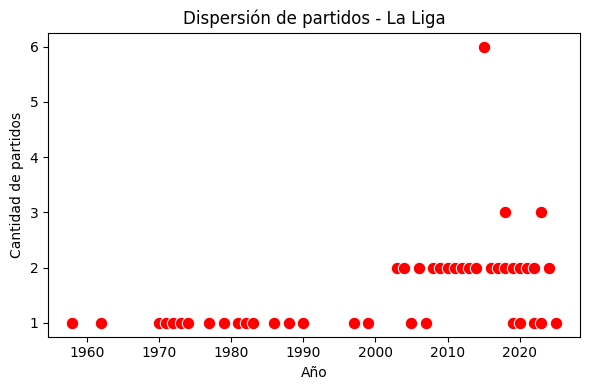

In [6]:
#cuenteo de partidos por temp
partidos_x_temp = competitions.groupby('season_name').size().reset_index(name='cantidad_partidos')
#Prueba grafica (x,y) donde se visualicen cant de partidos por año
partidos_x_temp['season_year'] = partidos_x_temp['season_name'].str[:4].astype(int)

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='season_year', 
    y='cantidad_partidos', 
    data=partidos_x_temp,
    s=80, color='red'
)
plt.xlabel('Año')
plt.ylabel('Cantidad de partidos')
plt.title('Dispersión de partidos - La Liga')
plt.tight_layout()
plt.show()


In [7]:
#variables - matches
#DEJAR EN EL DATASET: match_date; home_team; away_team;home_score; away_score; match_week; competition_stage; stadium; home_managers; away_managers
matches = sb.matches(competition_id=11,season_id=90);
matches.head(1)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,...,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2


Conociendo la ubicacion cronologica de la mayoria de los datos a trabajar, se comenzo el proceso de unificacion de tablas para asi hacer más valiosos y brindarle significado a cada uno de los datos. Como primer unificacion se junto la tabla de las 17 temporadas (competitions) con cada uno de sus partidos.

In [8]:
#merge de competitions + matches (mediante competition_id y season_id)
competition_id = 11
seasons = [37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]

competitions_reduce = sb.competitions()[['competition_id','season_id',
                                'competition_name','season_name','country_name']].drop_duplicates()

all_matches = []
for sid in seasons:
    m = sb.matches(competition_id=competition_id, season_id=sid)
    m['competition_id'] = 11
    m['season_id'] = sid

    m = m[['match_id','competition_id','season_id','match_date',
           'home_team','away_team','home_score','away_score',
           'match_week','competition_stage','stadium',
           'home_managers','away_managers']].copy()
    all_matches.append(m)

matches_df = pd.concat(all_matches, ignore_index=True)
# Ordenar por fecha descendente
matches_df = matches_df.sort_values('match_date', ascending=False).reset_index(drop=True)
# #sid == season_id
# #m == matches

merged = matches_df.merge(competitions_reduce, on=['competition_id','season_id'], how='left')

print(merged.shape)
merged


(867, 16)


,match_id,competition_id,season_id,match_date,home_team,away_team,home_score,away_score,match_week,competition_stage,stadium,home_managers,away_managers,competition_name,season_name,country_name
0,3773457,11,90,2021-05-16,Barcelona,Celta Vigo,1,2,37,Regular Season,Spotify Camp Nou,Ronald Koeman,Eduardo Germán Coudet,La Liga,2020/2021,Spain
1,3773387,11,90,2021-05-11,Levante UD,Barcelona,3,3,36,Regular Season,Estadio Ciudad de Valencia,Francisco José López Fernández,Ronald Koeman,La Liga,2020/2021,Spain
2,3773372,11,90,2021-05-08,Barcelona,Atlético Madrid,0,0,35,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Pablo Simeone,La Liga,2020/2021,Spain
3,3773695,11,90,2021-05-02,Valencia,Barcelona,2,3,34,Regular Season,Estadio de Mestalla,Javier Gracia Carlos,Ronald Koeman,La Liga,2020/2021,Spain
4,3773586,11,90,2021-04-29,Barcelona,Granada,1,2,33,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Martínez Penas,La Liga,2020/2021,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,68315,11,37,2004-12-21,Barcelona,Levante UD,2,1,17,Regular Season,Spotify Camp Nou,Frank Rijkaard,Bernd Schuster,La Liga,2004/2005,Spain
863,69153,11,37,2004-12-11,Albacete,Barcelona,1,2,15,Regular Season,Estadio Carlos Belmonte,José Manuel González López,Frank Rijkaard,La Liga,2004/2005,Spain
864,68314,11,37,2004-12-04,Barcelona,Málaga,4,0,14,Regular Season,Spotify Camp Nou,Frank Rijkaard,Gregorio Manzano Ballesteros,La Liga,2004/2005,Spain
865,68313,11,37,2004-10-24,Barcelona,Osasuna,3,0,8,Regular Season,Spotify Camp Nou,Frank Rijkaard,Javier Aguirre Onaindía,La Liga,2004/2005,Spain


Obteniendo esa unificacion, bien se sabe que en cada partido tiene miles de eventos. Por ello primero se filtraron las variables dentro de eventos (events). A continuacion

In [9]:
#Visualizacion de todas las variables de events
competition_id = 11
seasons = [37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]

all_types = set()
for sid in seasons:
    matches = sb.matches(competition_id, sid)
    for mid in matches['match_id']:
        ev = sb.events(match_id=mid)
        all_types.update(ev['type'].dropna().unique().tolist())

print(sorted(all_types))

['50/50', 'Bad Behaviour', 'Ball Receipt*', 'Ball Recovery', 'Block', 'Camera On', 'Camera off', 'Carry', 'Clearance', 'Dispossessed', 'Dribble', 'Dribbled Past', 'Duel', 'Error', 'Foul Committed', 'Foul Won', 'Goal Keeper', 'Half End', 'Half Start', 'Injury Stoppage', 'Interception', 'Miscontrol', 'Offside', 'Own Goal Against', 'Own Goal For', 'Pass', 'Player Off', 'Player On', 'Pressure', 'Referee Ball-Drop', 'Shield', 'Shot', 'Starting XI', 'Substitution', 'Tactical Shift']


In [10]:
all_events=[]

for sid in seasons:
    matches = sb.matches(competition_id,sid)
    for mid in matches['match_id']:
        ev = sb.events(match_id=mid)
        all_types.update(ev['type'].dropna().unique().tolist())
        filtered_ev=ev[ev['type'].isin(all_types)]
        all_events.append(filtered_ev)

events_df = pd.concat(all_events, ignore_index=True)
# display(events_df)

Por cada una de estas variables o columnas hay events  indivuales. Por ejemplo 'shot' -> se desglosa en algunos datos como 'shot_statsbomb_xg','shot_outcome' lo q se puede filtrar por jugador, minuto, partido, etc. 
Eventos posibles:['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Pressure'
 'Dribble' 'Duel' 'Clearance' 'Ball Recovery' 'Shot' 'Goal Keeper'
 'Interception' 'Miscontrol' 'Foul Committed' 'Foul Won' 'Dispossessed'
 'Dribbled Past' 'Block' 'Player Off' 'Player On' 'Substitution'
 'Tactical Shift' 'Half End' 'Injury Stoppage' 'Referee Ball-Drop' '50/50'
 'Shield' 'Offside' 'Bad Behaviour' 'Error' 'Own Goal For'
 'Own Goal Against' 'Camera off' 'Camera On']

 Cada uno de esos eventos da hincapie a seguir filtrando dentro de las posibles variables dentro statsbombpy. Muchos de ellos figuran NaN lo que significa que en ese momento talvez el evento fue un shot y por lo tanto todos los demás seran NaN .A continuacion se ven todas las variables psoibles:



In [11]:
#todas las variables psibles para filtrar datos
#87 variables
events = sb.events(match_id=3754037) 
events.columns

Index(['ball_receipt_outcome', 'ball_recovery_offensive',
       'ball_recovery_recovery_failure', 'carry_end_location',
       'clearance_aerial_won', 'clearance_body_part', 'clearance_head',
       'clearance_left_foot', 'clearance_right_foot', 'counterpress',
       'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome',
       'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive',
       'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive',
       'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome',
       'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id',
       'index', 'interception_outcome', 'location', 'match_id', 'minute',
       'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won',
       'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross',
       'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height',
   

Matriz de correlacion de todas las variables. Al ser la gran mayoria categoricas hay que solo tomar las numericas.

In [12]:
# Ver solo los tiros
shots = events_df[events_df['type'] == 'Shot']
print(shots[['player','team','minute','shot_end_location']].head())

                         player       team  minute   shot_end_location
2860  Miguel Ángel Lozano Ayala     Málaga       1  [120.0, 61.4, 1.9]
2861   Ronaldo de Assis Moreira  Barcelona      14  [120.0, 30.1, 0.6]
2862     Rafael Márquez Álvarez  Barcelona      15  [120.0, 37.2, 4.9]
2863       Andrés Iniesta Luján  Barcelona      22  [120.0, 46.1, 0.3]
2864         Samuel Eto''o Fils  Barcelona      24  [120.0, 42.8, 1.7]


ANÁLISIS GRÁFICO Y DESCRIPTIVO: A continuacion se hace un ejemplo del trabajo de datos para la obtencion de un heatmap de una cancha de juego que muestra en base a shot_end_location como finalizaron todos los tiros (shots) durante esas 17 temporadas

Total de tiros: 21182
Total de goles: 2653


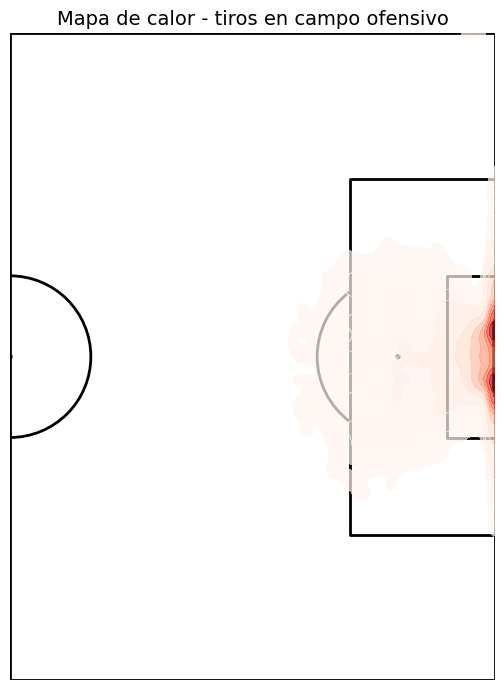

In [13]:
# Extraer tiros
shots = events_df[events_df['type'] == 'Shot'].dropna(subset=['shot_end_location']).copy()
shots[['x','y','z']] = pd.DataFrame(shots['shot_end_location'].tolist(), index=shots.index)

# Contar totales
total_shots = len(shots)
total_goals = shots['shot_outcome'].eq('Goal').sum()

print(f"Total de tiros: {total_shots}")
print(f"Total de goles: {total_goals}")

# Crear cancha (StatsBomb 120x80)
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10,7))

# Graficar solo medio campo ofensivo (x de 60 a 120)
ax.set_xlim(60, 120)
ax.set_ylim(0, 80)

# Heatmap
sns.kdeplot(
    x=shots['x'], y=shots['y'],
    fill=True, cmap="Reds", bw_adjust=0.5, alpha=0.7, ax=ax
)

ax.set_title("Mapa de calor - tiros en campo ofensivo", fontsize=14)
plt.show()

ANÁLISIS GRÁFICO Y DESCRIPTIVO: Entonces podemos ver el heatmap y ver que muchos de los tiros fueron al arco o cerca por la intesidad del calor, entonces a continuacion se grafica en un grafico de 3 dimensiones de puntos, todos los tiros en gris y en verde solo los que fueron goles

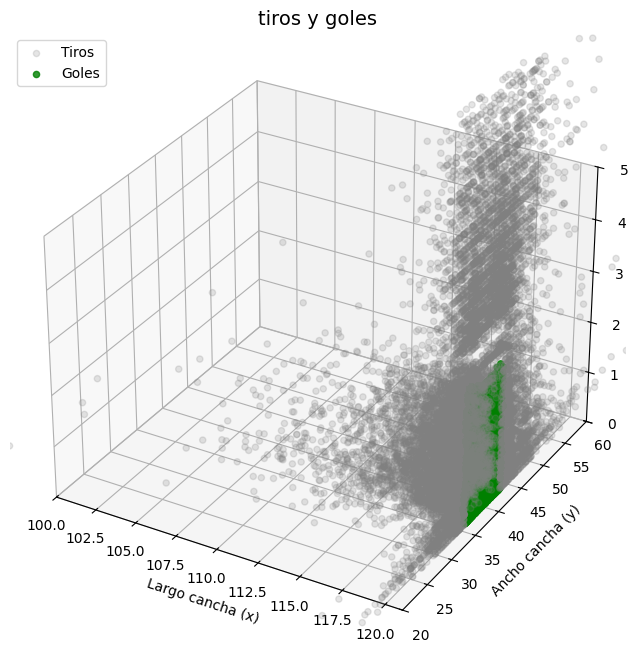

In [14]:
# Filtrar tiros y extraer coords
shots = events_df[events_df['type'] == 'Shot'].dropna(subset=['shot_end_location']).copy()
shots[['x','y','z']] = pd.DataFrame(shots['shot_end_location'].tolist(), index=shots.index)

# Separar goles y no goles
goals = shots[shots['shot_outcome'] == 'Goal']
no_goals = shots[shots['shot_outcome'] != 'Goal']

# Crear gráfico 3D
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# Tiros en gris
ax.scatter(no_goals['x'], no_goals['y'], no_goals['z'], 
           c='gray', alpha=0.2, label='Tiros')

# Goles en verde
ax.scatter(goals['x'], goals['y'], goals['z'], 
           c='green', alpha=0.8, label='Goles')

# Ajustar límites más amplios que antes (zoom intermedio)
ax.set_xlim(100, 121)   # antes era 110–121
ax.set_ylim(20, 60)     # antes era 30–50
ax.set_zlim(0, 5)       # antes era 0–3

# Etiquetas
ax.set_xlabel("Largo cancha (x)")
ax.set_ylabel("Ancho cancha (y)")
ax.set_zlabel("Altura (z)")
ax.set_title("tiros y goles", fontsize=14)

ax.legend()
plt.show()

Analisis de correlaciones: 

EJEMPLO DE MATRIZ CON RUIDO DE TODAS LAS VARIABLES

Como ejemplo se realizo un estudio posesion vs goles con la duda de si más posesión implica más goles. Primero se debe crear un dataset por partido agrupando la información a nivel de partido y equipo, resumiendo:

Posesión promedio.

Cantidad de goles anotados.

In [15]:
# Filtrar eventos con posesión y goles
df = events_df.copy()

# Crear columna de goles (1 si fue gol, 0 en caso contrario)
df['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)

# Agrupar por partido y equipo
team_stats = df.groupby(['match_id','team']).agg(
    possession_avg=('possession', 'mean'),   # promedio de posesión
    goals=('is_goal', 'sum')                 # goles marcados
).reset_index()

print(team_stats.head())


   match_id              team  possession_avg  goals
0      9575         Barcelona       81.205818      1
1      9575        Real Betis       82.930454      0
2      9581         Barcelona       83.948490      2
3      9581  Deportivo Alavés       97.968254      0
4      9592         Barcelona       80.653280      5


análisis gráfico

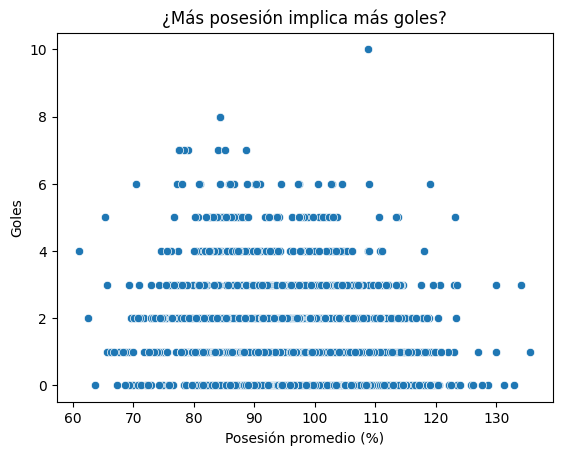

In [16]:
# Dispersión posesión vs goles
sns.scatterplot(x="possession_avg", y="goals", data=team_stats)
plt.title("¿Más posesión implica más goles?")
plt.xlabel("Posesión promedio (%)")
plt.ylabel("Goles")
plt.show()

correlación numérica del resultado grafico previo

In [17]:
# Correlación lineal
corr = team_stats['possession_avg'].corr(team_stats['goals'])
print(f"Correlación posesión vs goles: {corr:.2f}")


Correlación posesión vs goles: -0.16


Interpretación:

Si la correlación está cerca de 0 → no hay relación lineal clara (puede que equipos con más posesión no siempre marquen más).

Si es positiva → más posesión suele ir con más goles.

Si es negativa → más posesión no necesariamente significa más goles (ej: equipos que dominan pero no concretan).

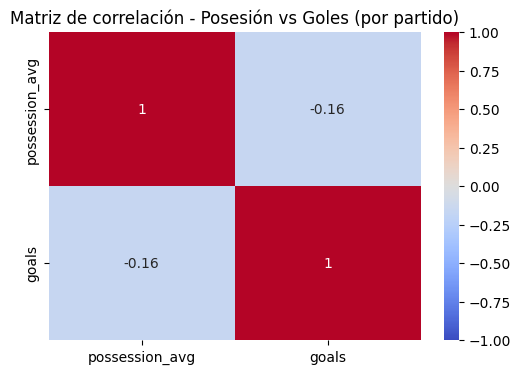

In [18]:

# Seleccionar solo las variables numéricas de interés
corr_vars = team_stats[['possession_avg', 'goals']]

# Calcular matriz de correlación
corr_matrix = corr_vars.corr()

# Graficar
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de correlación - Posesión vs Goles (por partido)", fontsize=12)
plt.show()


Matriz de correlacion 4x4: donde el xG (expectativa de gol) es la variable que realmente incide en la capacidad de hacer goles de un equipo o jugador

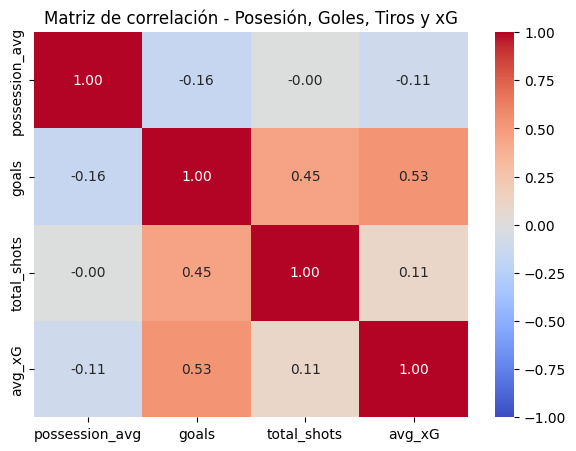

In [19]:
# Copia del dataframe de eventos
df = events_df.copy()

# Columna binaria de goles
df['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)

# Agrupar por partido y equipo
team_stats = df.groupby(['match_id','team']).agg(
    possession_avg=('possession','mean'),
    goals=('is_goal','sum'),
    total_shots=('id', lambda x: (df.loc[x.index, 'type'] == 'Shot').sum()),
    avg_xG=('shot_statsbomb_xg', 'mean')
).reset_index()

# Seleccionamos solo las variables numéricas de interés
corr_vars = team_stats[['possession_avg', 'goals', 'total_shots', 'avg_xG']]

# Calcular matriz de correlación
corr_matrix = corr_vars.corr()

# Graficar heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación - Posesión, Goles, Tiros y xG", fontsize=12)
plt.show()


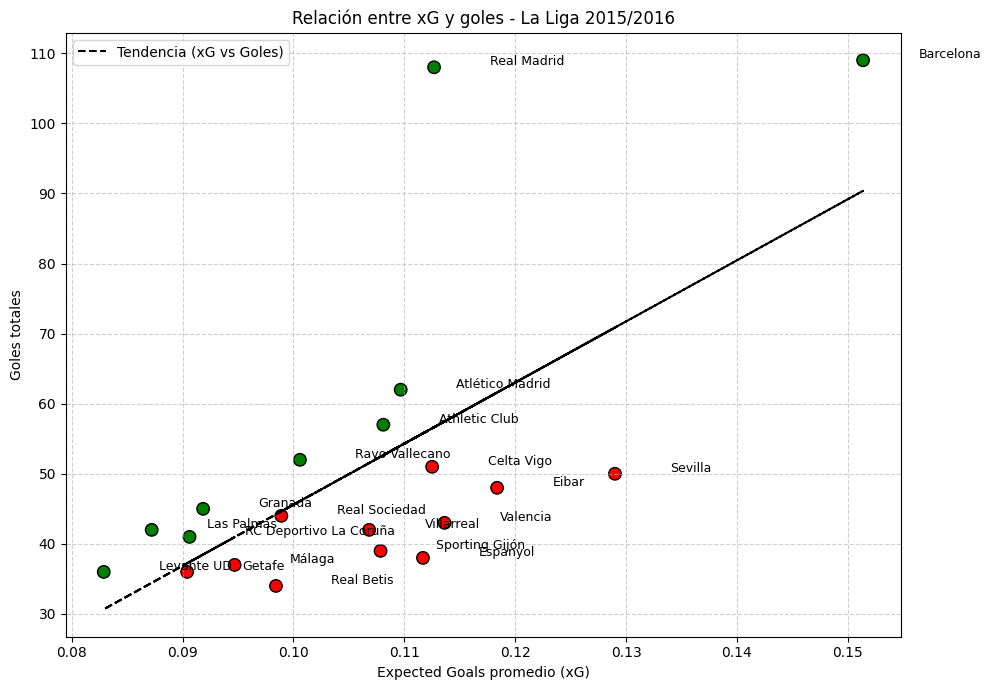

In [20]:
# 1. Filtrar solo La Liga 2015/2016 en matches
matches_2015 = matches_df[(matches_df['competition_id']==11) & (matches_df['season_id']==27)].copy()

# 2. Unir con events para traer los eventos de esos partidos
season_2015 = events_df.merge(
    matches_2015[['match_id','season_id','competition_id','home_team','away_team']], 
    on='match_id', how='inner'
)

# 3. Crear columna binaria de goles
season_2015['is_goal'] = (season_2015['shot_outcome'] == 'Goal').astype(int)

# 4. Agrupar por equipo
team_stats_2015 = season_2015.groupby('team').agg(
    goals=('is_goal','sum'),
    avg_xG=('shot_statsbomb_xg','mean')
).reset_index()

# --- Graficar dispersión ---
x = team_stats_2015['avg_xG']
y = team_stats_2015['goals']

plt.figure(figsize=(10,7))

# 5. Línea de regresión lineal
m, b = np.polyfit(x, y, 1)  # pendiente y ordenada
plt.plot(x, m*x + b, color="black", linestyle="--", label="Tendencia (xG vs Goles)")

# 6. Asignar color según rendimiento
colors = ['green' if actual > (m*exp + b) else 'red' for exp, actual in zip(x, y)]

plt.scatter(x, y, c=colors, s=80, edgecolors="k")

# 7. Etiquetas con nombres completos
for i, row in team_stats_2015.iterrows():
    plt.text(row['avg_xG']+0.005, row['goals']+0.3, row['team'], fontsize=9)

# Personalización
plt.xlabel("Expected Goals promedio (xG)")
plt.ylabel("Goles totales")
plt.title("Relación entre xG y goles - La Liga 2015/2016")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()




Metodos de clasificacion

Primero definimos y generamos agg_df -> un dataset agregado, osea una tabla resumen donde cada fila representa una unidad de análisis (por ejemplo, un equipo por temporada)
y las columnas contienen métricas estadísticas resumidas derivadas de los datos originales (eventos). Mientras que events_df contiene millones de filas (cada pase, tiro, recuperación, etc.), agg_df resume toda esa información a un nivel superior (por equipo y temporada),
convirtiendo datos de eventos en indicadores de rendimiento.

El proposito de crear esto:
1-Reducir complejidad — pasar de millones de filas a decenas o centenas sin perder información esencial.
2-Facilitar análisis estadístico y Machine Learning, ya que los algoritmos requieren entradas tabulares.
3-Comparar unidades entre sí (equipos, temporadas, jugadores, etc.) usando métricas comunes.
4-Detectar patrones globales: eficiencia, estilos de juego, rendimiento ofensivo o defensivo.

Se eligieron variables claras (fácil interpretación: goles, tiros, pases), disponibles en todas las temporadas y numéricas, para poder calcular promedios o proporciones.

In [25]:
# 1️⃣ Traer season_id y competition_id desde matches_df
# (asegúrate de tener matches_df cargado con esas columnas)
df = events_df.merge(
    matches_df[['match_id', 'season_id', 'competition_id']],
    on='match_id',
    how='left'
)

# 2️⃣ Crear columna binaria de goles
df['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)

# 3️⃣ Agrupar métricas por equipos y temporadas
# ---- PASES ----
passes = df[df['type'] == 'Pass']
passes_grouped = passes.groupby(['season_id', 'team']).agg(
    total_passes=('id', 'count'),
    completed_passes=('pass_outcome', lambda x: x.isna().sum()),
    avg_pass_length=('pass_length', 'mean')
).reset_index()

passes_grouped['pass_accuracy'] = (
    passes_grouped['completed_passes'] / passes_grouped['total_passes']
)

# ---- TIROS ----
shots = df[df['type'] == 'Shot']
shots_grouped = shots.groupby(['season_id', 'team']).agg(
    total_shots=('id', 'count'),
    goals=('is_goal', 'sum'),
    avg_xG=('shot_statsbomb_xg', 'mean')
).reset_index()

# ---- POSESIÓN ----
possession_grouped = df.groupby(['season_id', 'team']).agg(
    avg_possession=('possession', 'mean')
).reset_index()

# 4️⃣ Unificación de métricas
agg_df = passes_grouped.merge(shots_grouped, on=['season_id', 'team'], how='outer')
agg_df = agg_df.merge(possession_grouped, on=['season_id', 'team'], how='outer')

# 5️⃣ Limpieza y validación
agg_df.fillna(0, inplace=True)

# 6️⃣ Resultado
print(f"\nShape final: {agg_df.shape}")
#para validar que datos tiene pass_outcomes y asi poder validar 1 y 0 entre pases completados y no completados
print(df['pass_outcome'].unique()[:10])
display(agg_df.head(300))


Shape final: (322, 10)
[nan 'Incomplete' 'Out' 'Pass Offside' 'Unknown' 'Injury Clearance']


,season_id,team,total_passes,completed_passes,avg_pass_length,pass_accuracy,total_shots,goals,avg_xG,avg_possession
0,1,Athletic Club,842,624,23.430556,0.741093,27,0,0.072055,105.206841
1,1,Atlético Madrid,837,637,20.645761,0.761051,10,1,0.059274,101.546020
2,1,Barcelona,24158,20893,18.937971,0.864848,547,90,0.136709,90.039684
3,1,Celta Vigo,919,721,20.888169,0.784548,28,4,0.145847,92.080930
4,1,Deportivo Alavés,534,353,26.080608,0.661049,18,1,0.079795,102.621977
...,...,...,...,...,...,...,...,...,...,...
295,42,Osasuna,236,147,26.182711,0.622881,9,2,0.052680,105.544218
296,42,Real Betis,308,255,20.802644,0.827922,7,2,0.156425,75.363636
297,42,Real Madrid,1112,951,19.473613,0.855216,30,2,0.060652,100.747485
298,42,Real Sociedad,1083,915,19.996915,0.844875,29,2,0.118845,79.236863


En base a estos datos vamos a diferenciar equipos TOP en base a cantidad de goles, para poder asi tener una variable categorica en las clasficaciones

In [28]:
# Creamos una copia
df_model = agg_df.copy()

# Para cada temporada, marcamos a los equipos que están en el top 25% en goles
top_threshold = df_model.groupby('season_id')['goals'].transform(lambda x: x.quantile(0.75))
df_model['top_team'] = (df_model['goals'] >= top_threshold).astype(int)
display(df_model.head(5))

,season_id,team,total_passes,completed_passes,avg_pass_length,pass_accuracy,total_shots,goals,avg_xG,avg_possession,top_team
0,1,Athletic Club,842,624,23.430556,0.741093,27,0,0.072055,105.206841,0
1,1,Atlético Madrid,837,637,20.645761,0.761051,10,1,0.059274,101.546020,0
2,1,Barcelona,24158,20893,18.937971,0.864848,547,90,0.136709,90.039684,1
3,1,Celta Vigo,919,721,20.888169,0.784548,28,4,0.145847,92.080930,1
4,1,Deportivo Alavés,534,353,26.080608,0.661049,18,1,0.079795,102.621977,0


Pero esos equipos TOP no son tan reales porque la clasificacion de esos equipos era en base a los goles realizados durante las utlimas temproadas, donde unicamente se tomo el 25% superior de equipos por goles. Pero la realidad es que alguien que conoce de futbol y de la Liga sabe que más alla de sus resultados un equipo como por ejemplo el Atletico de Madrid no puede no entrar en la categoria TOP de la Liga. Por ende se opto por optimizar y hacer más realista la definicion de equipos tops en base a una metrica combinada entre goles, xG, precision en los pases y posesion promedio y ademas la definicion de algunos equipos TOP mediante propio conocimiento.

In [32]:
big_teams = ['Barcelona', 'Real Madrid', 'Atlético Madrid', 'Sevilla']
df_model['performance_score'] = (
    df_model['goals']*0.4 +
    df_model['avg_xG']*200 +
    df_model['pass_accuracy']*0.2 +
    df_model['avg_possession']*0.1
)

top_threshold = df_model.groupby('season_id')['performance_score'].transform(lambda x: x.quantile(0.75))

df_model['top_team'] = (
    (df_model['performance_score'] >= top_threshold) | 
    (df_model['team'].isin(big_teams))
).astype(int)

display(df_model.head(20))

,season_id,team,total_passes,completed_passes,avg_pass_length,pass_accuracy,total_shots,goals,avg_xG,avg_possession,top_team,performance_score
0,1,Athletic Club,842,624,23.430556,0.741093,27,0,0.072055,105.206841,0,25.079860
1,1,Atlético Madrid,837,637,20.645761,0.761051,10,1,0.059274,101.546020,1,22.561577
2,1,Barcelona,24158,20893,18.937971,0.864848,547,90,0.136709,90.039684,1,72.518667
3,1,Celta Vigo,919,721,20.888169,0.784548,28,4,0.145847,92.080930,1,40.134384
4,1,Deportivo Alavés,534,353,26.080608,0.661049,18,1,0.079795,102.621977,0,26.753361
5,1,Eibar,933,714,24.748963,0.765273,27,1,0.063366,99.150381,0,23.141230
6,1,Espanyol,507,311,23.902871,0.613412,16,1,0.064624,88.985461,0,22.345942
7,1,Getafe,539,338,26.880617,0.627087,23,1,0.045616,80.848135,0,17.733467
8,1,Girona,769,583,23.225212,0.758127,24,1,0.077148,97.404467,0,25.721612
9,1,Las Palmas,924,765,20.492213,0.827922,23,1,0.078563,91.304385,0,25.408619


kNN clasificador (TOP vs NO TOP)

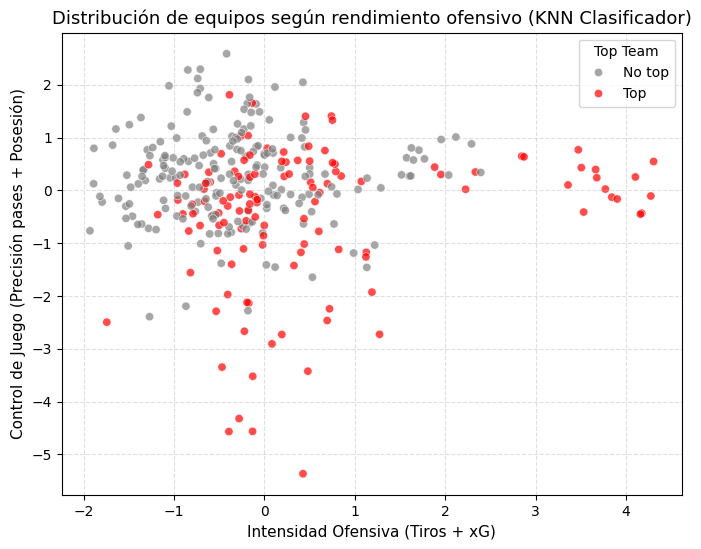

In [39]:
# Selección de variables
X = agg_df[['total_shots', 'avg_xG', 'pass_accuracy', 'avg_possession']]
y = df_model['top_team']

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducción a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# DataFrame para graficar
pca_df = pd.DataFrame(X_pca, columns=['Componente 1', 'Componente 2'])
pca_df['top_team'] = y.values

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df, 
    x='Componente 1', y='Componente 2',
    hue='top_team', 
    palette={0:'gray', 1:'red'},
    alpha=0.7
)
plt.title('Distribución de equipos según rendimiento ofensivo (KNN Clasificador)', fontsize=13)
plt.xlabel('Intensidad Ofensiva (Tiros + xG)', fontsize=11)
plt.ylabel('Control de Juego (Precisión pases + Posesión)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

# ✅ Arreglar la leyenda para que los colores sean correctos
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['No top', 'Top'], title='Top Team', loc='best')
plt.show()

Explicacion kNN clasificador (equipo TOP vs equipo NO TOP): 

-TOP: suele combinar gran volumen de oportunidades de gol (xG alto) con frecuencia de tiros, aunque no siempre tenga posesión dominante. Predomina la agresividad ofensiva productiva al control del juego. Sin embargo los mas TOP tienen ambas.
Ejemplo: un Real Madrid o un Barcelona en su mejor temporada pueden aparecer en esta zona, porque su producción ofensiva es explosiva.

-NO TOP: puede tener buen control del balón, pero falta de profundidad ofensiva.
Ejemplo: un Celta de Vigo o Getafe podría tener buena posesión media pero no suficiente capacidad para convertir en goles.

kNN Regresion (Objetivo: Predecir goles esperados o rendimiento continuo (en lugar de categorías))

In [41]:

# Variables predictoras
X = agg_df[['total_shots', 'avg_xG', 'pass_accuracy', 'avg_possession']]
y = agg_df['goals']

# Escalado
X_scaled = scaler.fit_transform(X)

# Entrenamiento/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Modelo
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)

# Evaluación
y_pred = knn_reg.predict(X_test)

# R² y RMSE
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R²: 0.9720376368474734
RMSE: 4.056711379491379


R2 (coeficiente de determinacion):mide qué proporción de la variabilidad total de la variable dependiente (en tu caso, los goles reales) puede explicarse por el modelo (usando tiros, xG, posesión y precisión de pases). En nuestro caso es casi 1 (100%), por lo tanto el modelo explica perfectamente todos los valores observados.
RMSE (Root Mean Squared Error (Error cuadrático medio)): mide cuánto se desvían las predicciones del modelo respecto a los valores reales, expresado en las mismas unidades de la variable original (en este caso, goles). En nuestro caso nos dio un +-4 por lo que es aceptable, entendiendo que de +-6 en adelnate ya seria alto y poco confiable. Y si lo pensamos tiene logica porque cada equipo suele tener mas de 100 goles y si solo se equivoca en +-4 no es muy significativo.

Grafico de comparacion de goles reales vs goles predichos. Los puntos cercanos a la linea roja son predicciones prefectas o casi perfecto. Mientras que los que se alejan son sobreestimacion o subestimaciones.

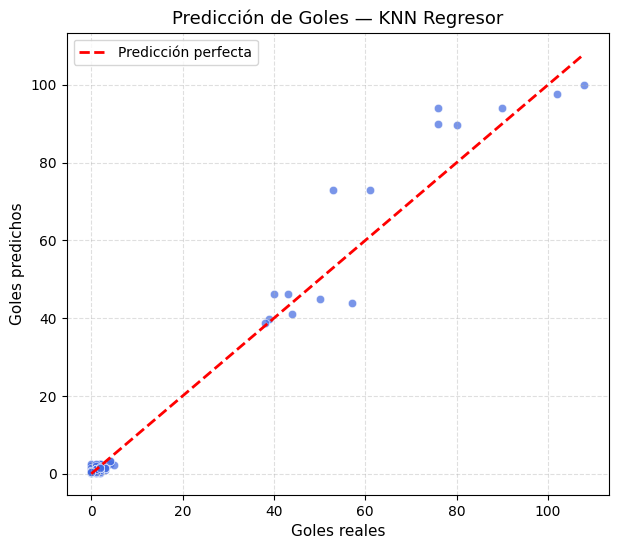

In [42]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='royalblue')

# Línea de referencia perfecta (predicción = realidad)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', color='red', linewidth=2, label='Predicción perfecta')

plt.title('Predicción de Goles — KNN Regresor', fontsize=13)
plt.xlabel('Goles reales', fontsize=11)
plt.ylabel('Goles predichos', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


Comparacion de valores por equipo

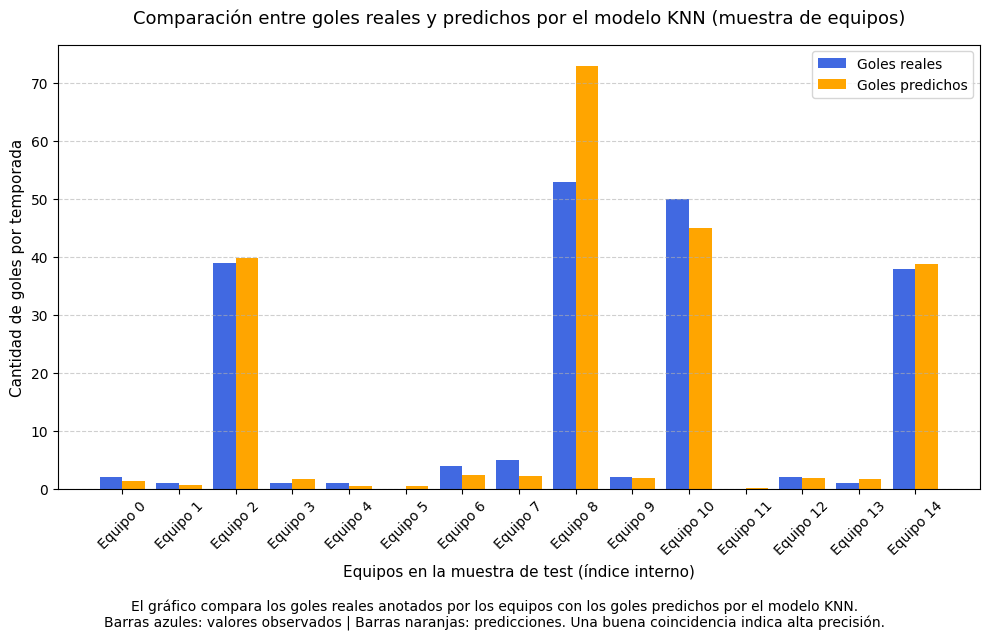

In [45]:
# Creamos el DataFrame con índices simples (en lugar de IDs)
comparison_df = pd.DataFrame({
    'Equipo (ID muestra)': range(len(y_test)),
    'Goles reales': y_test,
    'Goles predichos': y_pred
}).reset_index(drop=True)

# Seleccionamos los primeros 15 equipos para visualización
subset = comparison_df.head(15)

# --- GRAFICAMOS ---
plt.figure(figsize=(10,6))
plt.bar(subset.index - 0.2, subset['Goles reales'], width=0.4, label='Goles reales', color='royalblue')
plt.bar(subset.index + 0.2, subset['Goles predichos'], width=0.4, label='Goles predichos', color='orange')

# Etiquetas y estilo
plt.title('Comparación entre goles reales y predichos por el modelo KNN (muestra de equipos)', fontsize=13, pad=15)
plt.xlabel('Equipos en la muestra de test (índice interno)', fontsize=11)
plt.ylabel('Cantidad de goles por temporada', fontsize=11)
plt.xticks(subset.index, [f'Equipo {i}' for i in subset.index], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Texto interpretativo
plt.figtext(0.5, -0.05,
            "El gráfico compara los goles reales anotados por los equipos con los goles predichos por el modelo KNN.\n"
            "Barras azules: valores observados | Barras naranjas: predicciones. Una buena coincidencia indica alta precisión.",
            wrap=True, ha='center', fontsize=10)

plt.tight_layout()
plt.show()